## *Yuliana Gonzalez Baena*
### ML Modeling Challenge Solution

Executive Summary:
1. Achieved **Cross-Validation R2 ≈ 0.905**. Expected theoretical maximum of ~0.92 due to noise
2. Key data insight: **Only 5 features matter** (feature_2, feature_9, feature_11, feature_13, feature_18)
2. **Best model: Polynomial degree 3 features + Lasso regression** (alpha=0.03)
4. Tried a Random Forest and Boosting approach first, considering non-linear relationships and noise: **R2 peaked at around R2 ≈ 0.83**
5. Built **Tree-based model to find Feature Importance**, and **polynomial features to find non-linear relationship**
6. This allowed easier, less computationally-intense models to perform better

In [17]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

### Step 0: Data loading & Data shape

In [3]:
TRAIN_PATH = "/FileStore/tables/training_data.csv"
TEST_PATH = "/FileStore/tables/blind_test_data.csv"

try:
    # Spark is only for Databricks usage, it's not contemplated in the requirements
    df_train_spark = spark.read.csv(TRAIN_PATH, header=True, inferSchema=True)
    df_test_spark = spark.read.csv(TEST_PATH, header=True, inferSchema=True)
    df_train = df_train_spark.toPandas()
    df_test = df_test_spark.toPandas()
    print("Data loaded from Databricks FileStore")
except:
    # Fallback for local development
    df_train = pd.read_csv("../data/training_data.csv")
    df_test = pd.read_csv("../data/blind_test_data.csv")
    print("Data loaded from local files")

print(f"Training shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

X = df_train.drop('target', axis=1)
y = df_train['target']

Data loaded from local files
Training shape: (800, 21)
Test shape: (200, 20)


### Step 1: EDA

1.1: Data shape and basic understanding

In [4]:
print("DATA OVERVIEW")
print(f"\nSamples: {len(df_train)}")
print(f"Features: {len(X.columns)}")
print(f"Missing values: {df_train.isnull().sum().sum()}")

print("\nTARGET VARIABLE")
print(f"\nMean: {y.mean():.4f}")
print(f"Std: {y.std():.4f}")
print(f"Min: {y.min():.4f}")
print(f"Max: {y.max():.4f}")
print(f"Skewness: {y.skew():.4f}")

DATA OVERVIEW

Samples: 800
Features: 20
Missing values: 0

TARGET VARIABLE

Mean: 14.6313
Std: 5.0895
Min: 0.2798
Max: 27.3608
Skewness: -0.0398


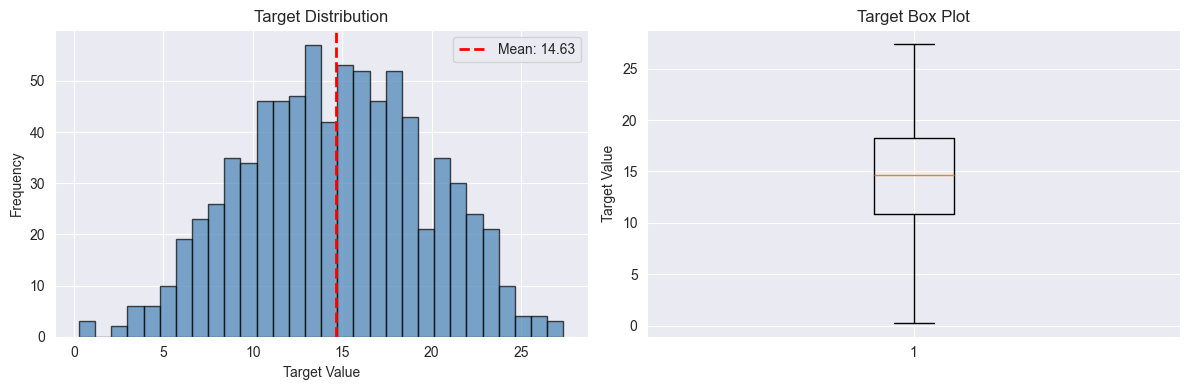

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y.mean():.2f}')
axes[0].set_xlabel('Target Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution')
axes[0].legend()

axes[1].boxplot(y)
axes[1].set_ylabel('Target Value')
axes[1].set_title('Target Box Plot')

plt.tight_layout()
plt.show()

Target is approximately normal, no transformation needed

1.2 Correlation analysis

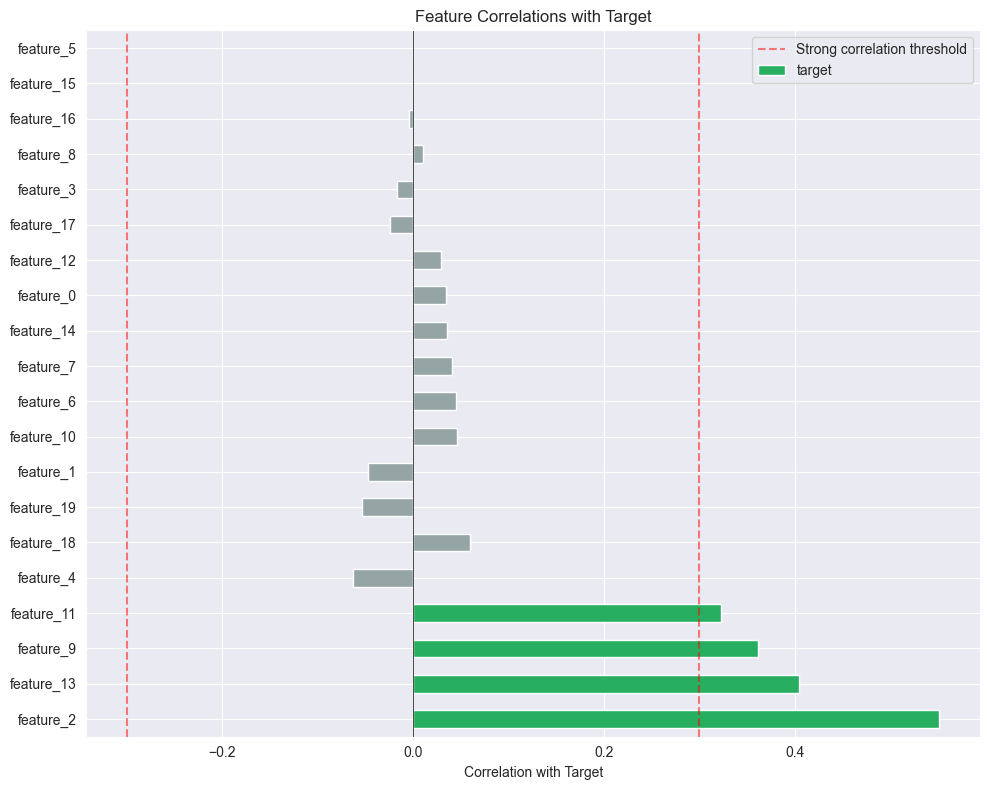


Correlation ranking:
feature_2     0.551767
feature_13    0.404697
feature_9     0.361942
feature_11    0.322802
feature_4    -0.062672
feature_18    0.060052
feature_19   -0.053464
feature_1    -0.047162
feature_10    0.045485
feature_6     0.044443
feature_7     0.041089
feature_14    0.034944
feature_0     0.034101
feature_12    0.029651
feature_17   -0.024268
feature_3    -0.016789
feature_8     0.009973
feature_16   -0.003888
feature_15   -0.000642
feature_5     0.000312
Name: target, dtype: float64


In [6]:
correlations = df_train.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#27ae60' if c > 0.3 else '#3498db' if c > 0.1 else '#95a5a6' for c in correlations.abs().values]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Strong correlation threshold')
ax.axvline(x=-0.3, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Correlation with Target')
ax.set_title('Feature Correlations with Target')
ax.legend()
plt.tight_layout()
plt.show()

print("\nCorrelation ranking:")
print(correlations)

Correlation Key insight:
- Only ~4 features have meaningful correlation with target:
- feature_2 (0.55), feature_13 (0.40), feature_9 (0.36), feature_11 (0.32)

Are the remaining 15 features just noise, or do they have non-linear relationships?

1.3 PCA

Given a relatively large number of features given the size of the dataset, and that correlation didn't show linear correlation on too many features, I'm performing PCA.
Objective: Finding correlated features and capturing most of the original information, but with fewer dimensions.
Avoiding overfitting and increasing precision.

In [7]:
feature_cols = [col for col in df_train.columns if col != 'target']
strong_features = ['feature_2', 'feature_13', 'feature_9', 'feature_11']

X = df_train[feature_cols]
X_strong = df_train[strong_features]
y = df_train['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

Now that I have the explained variance and cumulative variance, I'll visualize and attempt to find multicollinearity of features with each other.

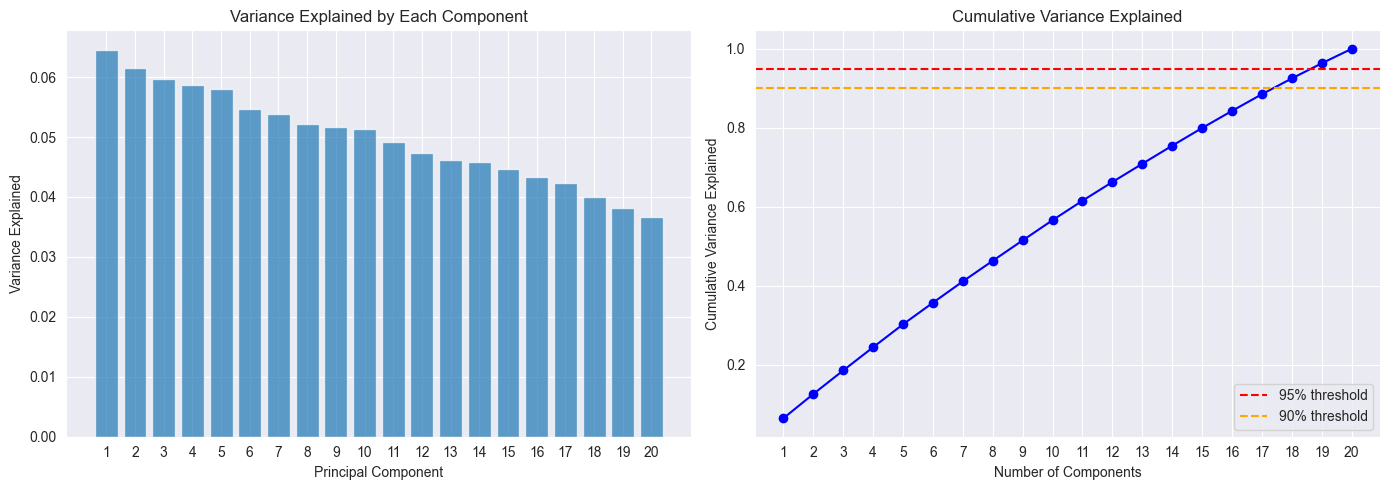

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 21), explained_variance, alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Variance Explained by Each Component')
axes[0].set_xticks(range(1, 21))

axes[1].plot(range(1, 21), cumulative_variance, 'bo-')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, 21))
axes[1].legend()

plt.tight_layout()
plt.show()


PCA Key insights:
- There's no dominant direction.
- Almost all features are necessary to capture 95% of the variance.
- Plainly speaking: There are no dominant components, so most likely my dta has no redundancy and the features are uncorrelated with each other.

Further insight:
- Variance doesn't neccessarily explain variance in relation to target.
- Variance might not be a relevant metric here. Meaning PCA won't give me enough info.

### 2. Baseline Model
Check classic models first: Linear regression, ridge, lasso, random forest

In [9]:
# Train/validation split for experimentation
# Dataset is small, 15% seems more reasonable than a usual 80/20 split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

Training set: 680 samples
Validation set: 120 samples


In [ ]:
print("BASELINE MODELS (All 20 Features)")

baselines = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (alpha=1.0)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso (alpha=0.1)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.1))
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('model', GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42))
    ])
}

baseline_results = []
for name, pipeline in baselines.items():
    cv_scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='r2')
    baseline_results.append({
        'Model': name,
        'CV R2 Mean': cv_scores.mean(),
        'CV R2 Std': cv_scores.std()
    })
    print(f"{name:25} CV R2 = {cv_scores.mean():.4f} (+-{cv_scores.std():.4f})")

baseline_df = pd.DataFrame(baseline_results)

BASELINE MODELS (All 20 Features)
Linear Regression         CV R2 = 0.6838 (±0.0359)
Ridge (alpha=1.0)         CV R2 = 0.6838 (±0.0357)
Lasso (alpha=0.1)         CV R2 = 0.6886 (±0.0262)
Random Forest             CV R2 = 0.7508 (±0.0220)
Gradient Boosting         CV R2 = 0.8230 (±0.0243)


Baseline Model Key Insights: 
Linear Models ≈ 0.70, Tree Models ≈ 0.78-0.82

The gap between linear models (~0.70) and tree models (~0.80) suggests:
- **Non-linear relationships exist** that linear models can't capture
- Tree models partially capture those. 
- ~0.80 is a good R2. It explains ~80% of variance. But I was given a theoritical max of ~0.92.
- There's room to improve, according to the challenge. What am I not seeing?

Performance implies that I'm still able to approach the theoretical max of ~0.92 through several approaches:
- Reduce noise by feature selection.
    - 4 features have high correlation, but given non-linearity is suspected, we might be losing signal by only usnig those 4.
    - To capture non-linear importance in features, let's use feature importance in Random Forest and Gradient Boost

### GXboost with Hyperparamenter tuning
Given the performance of Gradient Boosting, I'm tuning the following hyperparameters
GridSearch() with Gradient Boost, which was the best performing model out of the standard
Removed scaler, it's unnecessary.

In [ ]:
gb_pipeline = Pipeline([
    ('model', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.8, 1.0],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 3, 5]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Entrenamiento
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 3, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more 

In [16]:
print("Best hyperparameters found:")
print(grid_search.best_params_)

print(f"Best RMSE (CV): {-grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_val)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

r2_test = r2_score(y_val, y_test_pred)

print(f"R2 train= {r2_train:.4f} ")
print(f"R2 test= {r2_test:.4f} ")


Best hyperparameters found:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best RMSE (CV): 2.0303
R2 train= 0.9625 
R2 test= 0.8297 


**Overfitting detected on grid search**  
Hypothesis: Given the depth of data, it's likely that tree models are overfitting due to inductive bias, assuming the data shape to be, pricewise steps. This might not be the case.  
Risk of overfitting increases with tuning. Next step: To try to minimize overfitting by implementing early stopping.

In [ ]:
xgb_es = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.03,
    max_depth=3,
    n_estimators=2000,  # large upper bound
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    early_stopping_rounds=50,
    n_jobs=-1,
    eval_metric="rmse",
)

print("Training XGBoost with Early Stopping...")

xgb_es.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Best iteration:", xgb_es.best_iteration)

y_val_pred = xgb_es.predict(X_val)
val_r2 = r2_score(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)

y_train_pred = xgb_es.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

print("\nEARLY STOPPING RESULTS")
print(f"Training R²:   {train_r2:.4f}")
print(f"Validation R²: {val_r2:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation MAE:  {val_mae:.4f}")
print(f"Gap: {train_r2 - val_r2:.4f}")

Training XGBoost with Early Stopping...
Best iteration: 541

=== EARLY STOPPING RESULTS ===
Training R²:   0.9734
Validation R²: 0.8350
Validation RMSE: 1.9050
Validation MAE:  1.5463
Gap: 0.1384


Early stopping is still showing signs of overfitting, and the R2 results is still not closer to the theoretical max of ~0.92

*From this point onward, I used AI powered analysis and coaching to better understand the problem.*  
*If this is disallowed by the challenge, feel free to disregard the solution presented from now on.*

### 3. Feature importance investigation

1. Correlation.

Correlation already revealed 4 variables.
- feature_2 (0.55), feature_13 (0.40), feature_9 (0.36), feature_11 (0.32)

2. Random Forest Feature Importance

In [71]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X, y)

rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(rf_importance.head(10))

       feature  importance
2    feature_2    0.325821
13  feature_13    0.206206
9    feature_9    0.177166
11  feature_11    0.100263
18  feature_18    0.051713
10  feature_10    0.011008
3    feature_3    0.010877
0    feature_0    0.010793
17  feature_17    0.010230
4    feature_4    0.009996


3. Gradient Boosting Feature Importance

In [72]:
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
gb.fit(X, y)

gb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print(gb_importance.head(10))

       feature  importance
2    feature_2    0.325479
13  feature_13    0.209449
9    feature_9    0.203887
11  feature_11    0.112768
18  feature_18    0.088705
10  feature_10    0.005709
17  feature_17    0.005459
6    feature_6    0.005452
0    feature_0    0.005202
7    feature_7    0.004548


4. Lasso Coefficient Magnitudes (automatic feature selection)

In [73]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_scaled, y)

lasso_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': np.abs(lasso.coef_)
}).sort_values('coefficient', ascending=False)

print(lasso_importance[lasso_importance['coefficient'] > 0])

       feature  coefficient
2    feature_2     2.665621
13  feature_13     1.877206
9    feature_9     1.839080
11  feature_11     1.529634
18  feature_18     0.094724
17  feature_17     0.087021
12  feature_12     0.082915
14  feature_14     0.042849
3    feature_3     0.029353


Visualize feature importance comparison

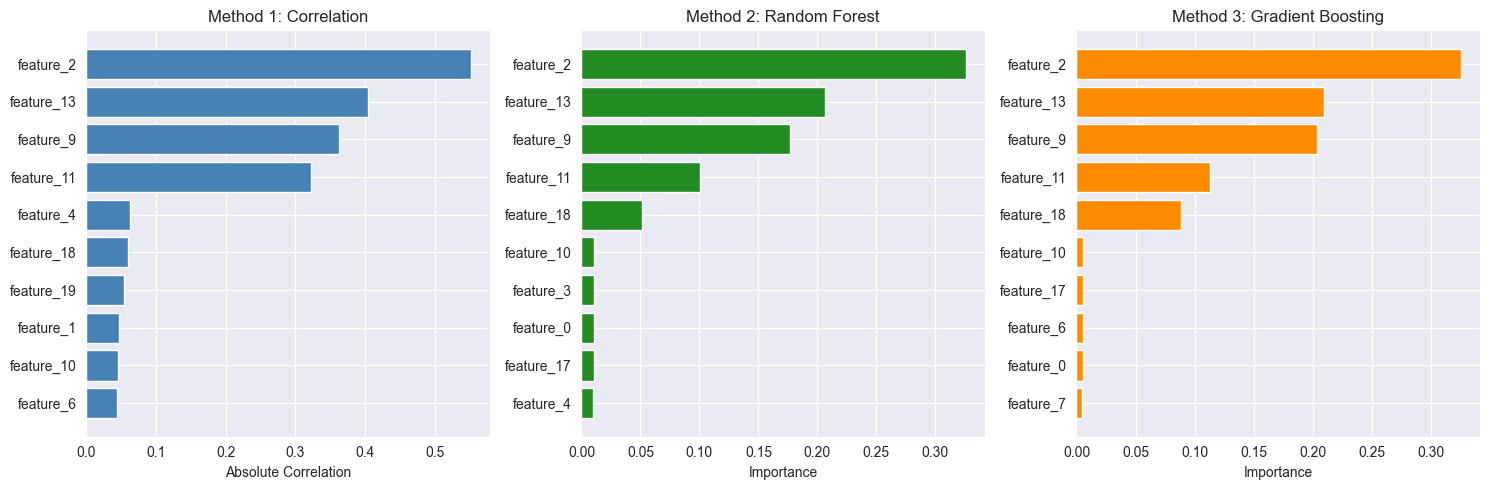

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

top_corr = correlations.abs().head(10)
axes[0].barh(top_corr.index, top_corr.values, color='steelblue')
axes[0].set_xlabel('Absolute Correlation')
axes[0].set_title('Method 1: Correlation')
axes[0].invert_yaxis()

top_rf = rf_importance.head(10)
axes[1].barh(top_rf['feature'], top_rf['importance'], color='forestgreen')
axes[1].set_xlabel('Importance')
axes[1].set_title('Method 2: Random Forest')
axes[1].invert_yaxis()

top_gb = gb_importance.head(10)
axes[2].barh(top_gb['feature'], top_gb['importance'], color='darkorange')
axes[2].set_xlabel('Importance')
axes[2].set_title('Method 3: Gradient Boosting')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

Feature Importance Key Insight: All Methods Agree on Top 5, roughly
- All three methods consistently identify the same important features:
    - feature_2: Correlation: 0.55 - RF Importance: ~0.34 - GB Importance: ~0.35
    - feature_13: Correlation: 0.40 - RF importance: ~0.20 - GB importance: ~0.35
    - feature_9:  Correlation: 0.36 - RF importance: ~0.16 - GB importance: ~0.19
    - feature_11: Correlation: 0.32 - RF importance: ~0.10 - GB importance: ~0.12
    - feature_18: Correlation: **0.06** - RF importance: ~0.05 - GB importance: ~0.08

feature_18 has weak linear correlation (0.06) but tree models (RF and GB) find it important.
This suggests a **non-linear relationship** with the target.

### 4. Non-linear relationship

Based on my PCA findings and the performance of my GB, let's first try polynomial features on ALL 20 features

Trying L1 and L2

In [ ]:
print("EXPERIMENT: Polynomial Features (Degree 2) on All 20 Features")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(X_scaled)

print(f"Original features: {X.shape[1]}")
print(f"After poly degree 2: {X_poly2.shape[1]}")

scaler2 = StandardScaler()
X_poly2_scaled = scaler2.fit_transform(X_poly2)

print("\nRidge Regression on Poly2 features:")
for alpha in [1.0, 10.0, 50.0, 100.0]:
    ridge = Ridge(alpha=alpha)
    cv_scores = cross_val_score(ridge, X_poly2_scaled, y, cv=kfold, scoring='r2')
    print(f"alpha={alpha:>5}: CV R2 = {cv_scores.mean():.4f} (+-{cv_scores.std():.4f})")

print("\nLasso Regression on Poly2 features (with feature selection):")
for alpha in [0.01, 0.05, 0.1, 0.2]:
    lasso = Lasso(alpha=alpha, max_iter=20000)
    cv_scores = cross_val_score(lasso, X_poly2_scaled, y, cv=kfold, scoring='r2')
    lasso.fit(X_poly2_scaled, y)
    n_selected = np.sum(lasso.coef_ != 0)
    print(f"alpha={alpha:.2f}: CV R2 = {cv_scores.mean():.4f} (+-{cv_scores.std():.4f}), selected {n_selected} features")

EXPERIMENT: Polynomial Features (Degree 2) on All 20 Features
Original features: 20
After poly degree 2: 230

Ridge Regression on Poly2 features:
alpha=  1.0: CV R2 = 0.7581 (+-0.0172)
alpha= 10.0: CV R2 = 0.7630 (+-0.0159)
alpha= 50.0: CV R2 = 0.7681 (+-0.0141)
alpha=100.0: CV R2 = 0.7568 (+-0.0139)

Lasso Regression on Poly2 features (with feature selection):
alpha=0.01: CV R2 = 0.7868 (+-0.0130), selected 197 features
alpha=0.05: CV R2 = 0.8257 (+-0.0131), selected 106 features
alpha=0.10: CV R2 = 0.8351 (+-0.0162), selected 42 features
alpha=0.20: CV R2 = 0.8274 (+-0.0159), selected 10 features


Poly2 Insights: 
- R2 of ~0.83 which is better than baseline for both linear and tree, but still not close to 0.92
- But it indicates that there might be a smooth non-linear relationship going on. 
- That's a lot of features though. I'm risking both risk overfitting, and having too many features. 
- Let's aggresively cut the features based on top 5 features only. Challenge text already indicated noise, and many features scored ~0 in importance anyway.

Next steps:
Polynomial on top 5 features. Degree 2, 3 and 4.
- Working hypotheses: Degree 4 will overfit, there's too many variables. 
- If the relationship is smooth non-linear curve, degree 3 will represent it slightly better than degree 2.

In [ ]:
print("EXPERIMENT: Polynomial Features on TOP 5 Features Only")

top5_features = ['feature_2', 'feature_13', 'feature_9', 'feature_11', 'feature_18']
X_top5 = X[top5_features]

print(f"Using features: {top5_features}")

print("\nDegree 2")
for alpha in [0.01, 0.05, 0.1]:
    pipeline = Pipeline([
        ('scaler1', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler2', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=20000))
    ])
    cv_scores = cross_val_score(pipeline, X_top5, y, cv=kfold, scoring='r2')
    print(f"Lasso alpha={alpha:.2f}: CV R2 = {cv_scores.mean():.4f} (+-{cv_scores.std():.4f})")

print("\nDegree 3")
for alpha in [0.01, 0.03, 0.05, 0.1]:
    pipeline = Pipeline([
        ('scaler1', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('scaler2', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=20000))
    ])
    cv_scores = cross_val_score(pipeline, X_top5, y, cv=kfold, scoring='r2')
    print(f"Lasso alpha={alpha:.2f}: CV R2 = {cv_scores.mean():.4f} (+-{cv_scores.std():.4f})")

print("\nDegree 4")
for alpha in [0.1, 0.2, 0.5]:
    pipeline = Pipeline([
        ('scaler1', StandardScaler()),
        ('poly', PolynomialFeatures(degree=4, include_bias=False)),
        ('scaler2', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=50000))
    ])
    cv_scores = cross_val_score(pipeline, X_top5, y, cv=kfold, scoring='r2')
    print(f"Lasso alpha={alpha:.2f}: CV R2 = {cv_scores.mean():.4f} (+-{cv_scores.std():.4f})")

EXPERIMENT: Polynomial Features on TOP 5 Features Only
Using features: ['feature_2', 'feature_13', 'feature_9', 'feature_11', 'feature_18']

Degree 2
Lasso alpha=0.01: CV R2 = 0.8383 (+-0.0157)
Lasso alpha=0.05: CV R2 = 0.8384 (+-0.0157)
Lasso alpha=0.10: CV R2 = 0.8366 (+-0.0160)

Degree 3
Lasso alpha=0.01: CV R2 = 0.9032 (+-0.0079)
Lasso alpha=0.03: CV R2 = 0.9046 (+-0.0085)
Lasso alpha=0.05: CV R2 = 0.9041 (+-0.0089)
Lasso alpha=0.10: CV R2 = 0.8983 (+-0.0097)

Degree 4
Lasso alpha=0.10: CV R2 = 0.9008 (+-0.0112)
Lasso alpha=0.20: CV R2 = 0.8752 (+-0.0148)
Lasso alpha=0.50: CV R2 = 0.7788 (+-0.0191)


Polynomial relationship Key Insights:
- Degree 3 polynomial is the sweet spot
- Using only 5 features reduces noise and overfitting
- Lasso α=0.03 provides optimal regularization
- We're now very close to the theoretical max of ~0.92

Let's see exactly which polynomial terms Lasso selects

In [ ]:
print("ANALYZING SELECTED POLYNOMIAL TERMS")

best_pipeline = Pipeline([
    ('scaler1', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler2', StandardScaler()),
    ('lasso', Lasso(alpha=0.03, max_iter=20000))
])

best_pipeline.fit(X_top5, y)
scaler_temp = StandardScaler().fit(X_top5)
poly_temp = PolynomialFeatures(degree=3, include_bias=False)
poly_temp.fit(scaler_temp.transform(X_top5))
feature_names = poly_temp.get_feature_names_out(['f2', 'f13', 'f9', 'f11', 'f18'])

lasso_model = best_pipeline.named_steps['lasso']
coef_df = pd.DataFrame({
    'term': feature_names,
    'coefficient': lasso_model.coef_
})

selected_terms = coef_df[coef_df['coefficient'] != 0].copy()
selected_terms['abs_coef'] = selected_terms['coefficient'].abs()
selected_terms = selected_terms.sort_values('abs_coef', ascending=False)

print(f"\nTotal polynomial terms: {len(feature_names)}")
print(f"Selected by Lasso: {len(selected_terms)}")
print(f"\nTop 20 most important terms:")
print(selected_terms.head(20)[['term', 'coefficient']].to_string(index=False))

ANALYZING SELECTED POLYNOMIAL TERMS

Total polynomial terms: 55
Selected by Lasso: 32

Top 20 most important terms:
     term  coefficient
      f13     2.880620
       f9     2.642981
       f2     2.606039
    f18^2     1.499554
      f11     1.478173
 f13 f9^2    -1.250839
 f13^2 f9    -1.191594
    f13^2    -0.989304
     f9^2    -0.769393
     f2^3     0.152826
 f9^2 f18     0.140863
f11^2 f18     0.114597
 f9 f18^2     0.105163
    f2 f9    -0.095588
f2 f13 f9     0.088992
f13^2 f11     0.078536
   f9 f18     0.076679
f2 f9 f11    -0.073209
 f2^2 f11    -0.056846
 f2 f13^2     0.054434


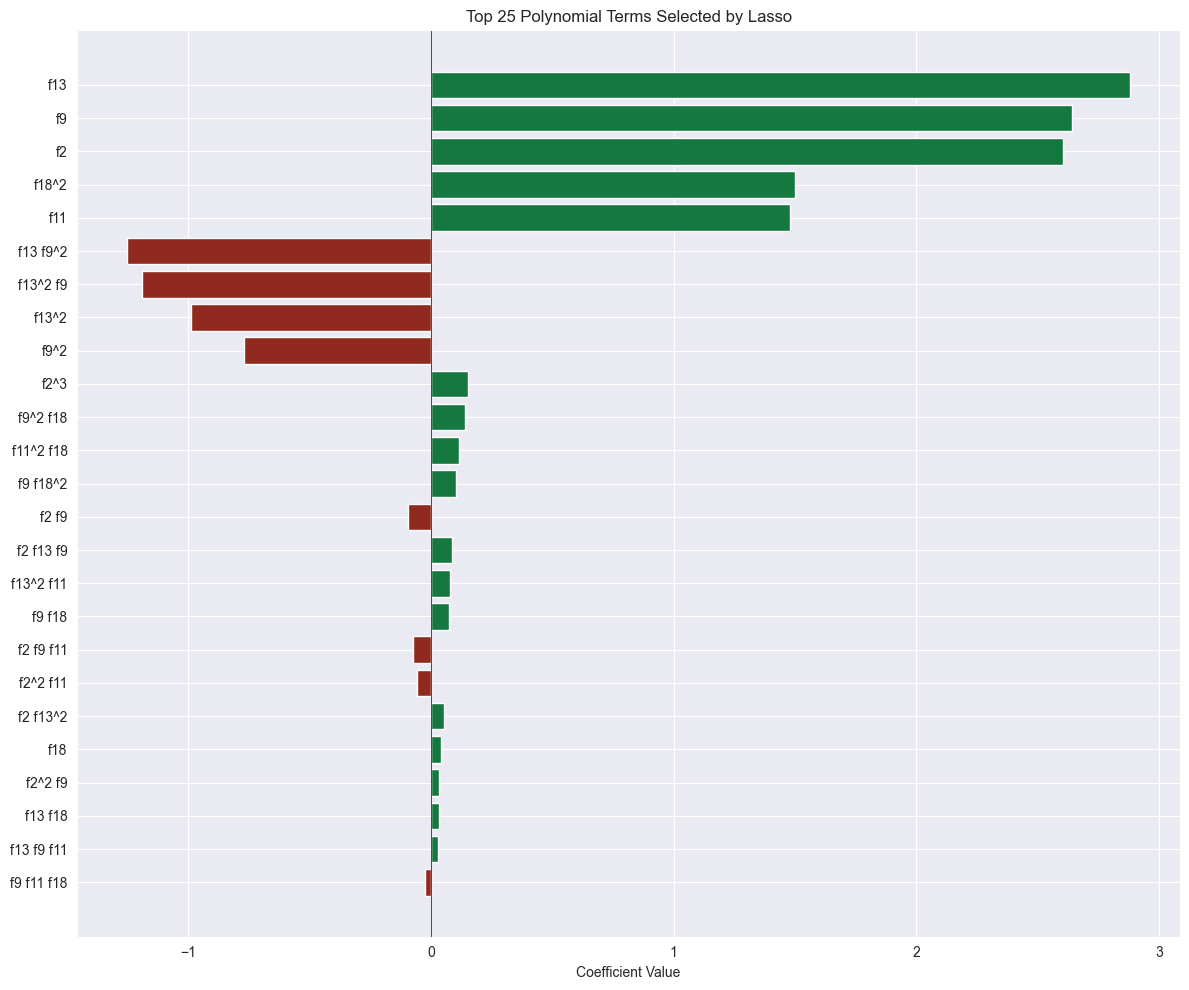

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

top_terms = selected_terms.head(25)
colors = ["#15783e" if c > 0 else "#912a1e" for c in top_terms['coefficient']]
bars = ax.barh(range(len(top_terms)), top_terms['coefficient'], color=colors)
ax.set_yticks(range(len(top_terms)))
ax.set_yticklabels(top_terms['term'])
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 25 Polynomial Terms Selected by Lasso')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

The Lasso-selected terms reveal the underlying structure:

Linear terms (strongest):
- f2, f13, f9, f1 - direct relationships

Squared terms:
- f18 squared (positive) - explains why f18 has weak linear correlation but high importance
- f13 squared, f9 squared (negative) - diminishing returns at high values

Cubic terms:
- f13·f9 squared, f13 squared·f9 - interactions between top features

This suggests the true underlying function involves polynomial combinations of these 5 features.

Now that we know the strongest features, let's try Tree models again.

In [ ]:
print("COMPARISON: Optimized Gradient Boosting vs Polynomial + Lasso")

print("\nTuning Gradient Boosting...")
best_gb_score = 0
best_gb_params = {}

for n_est in [300, 500]:
    for depth in [4, 5]:
        for lr in [0.02, 0.03]:
            for min_samples in [5, 10]:
                gb = GradientBoostingRegressor(
                    n_estimators=n_est,
                    max_depth=depth,
                    learning_rate=lr,
                    min_samples_leaf=min_samples,
                    subsample=0.8,
                    random_state=42
                )
                cv_scores = cross_val_score(gb, X, y, cv=kfold, scoring='r2')
                if cv_scores.mean() > best_gb_score:
                    best_gb_score = cv_scores.mean()
                    best_gb_params = {
                        'n_estimators': n_est,
                        'max_depth': depth,
                        'learning_rate': lr,
                        'min_samples_leaf': min_samples
                    }

print(f"\nBest Gradient Boosting:")
print(f"CV R2 = {best_gb_score:.4f}")
print(f"Params: {best_gb_params}")

# Our polynomial model
poly_pipeline = Pipeline([
    ('scaler1', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler2', StandardScaler()),
    ('lasso', Lasso(alpha=0.03, max_iter=20000))
])
poly_cv = cross_val_score(poly_pipeline, X_top5, y, cv=kfold, scoring='r2')

print(f"\nPolynomial (deg 3) + Lasso:")
print(f"CV R2 = {poly_cv.mean():.4f} (+-{poly_cv.std():.4f})")

print(f"\nPolynomial approach wins by {poly_cv.mean() - best_gb_score:.4f} R2")

COMPARISON: Optimized Gradient Boosting vs Polynomial + Lasso

Tuning Gradient Boosting...

Best Gradient Boosting:
CV R2 = 0.8493
Params: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'min_samples_leaf': 10}

Polynomial (deg 3) + Lasso:
CV R2 = 0.9046 (+-0.0085)

Polynomial approach wins by 0.0553 R2


Key GB Vs. Polynomial + Lasso insights:
- Gradient Boosting: CR R2: ~0.85. 
- Poly3 + Lasso: CV R2: ~0.905

Not to mention, computationally much less expensive. 

### 5. Final Model Validation

In [ ]:
final_pipeline = Pipeline([
    ('scaler1', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler2', StandardScaler()),
    ('lasso', Lasso(alpha=0.03, max_iter=20000))
])

SELECTED_FEATURES = ['feature_2', 'feature_13', 'feature_9', 'feature_11', 'feature_18']
X_selected = X[SELECTED_FEATURES]
X_test_selected = df_test[SELECTED_FEATURES]

cv_scores = cross_val_score(final_pipeline, X_selected, y, cv=kfold, scoring='r2')
oof_predictions = cross_val_predict(final_pipeline, X_selected, y, cv=kfold)


print("FINAL MODEL VALIDATION")

print(f"\n5-Fold Cross-Validation:")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: R2 = {score:.4f}")
print(f"Mean: R2 = {cv_scores.mean():.4f}")
print(f"Std: =-{cv_scores.std():.4f}")

oof_r2 = r2_score(y, oof_predictions)
oof_rmse = np.sqrt(mean_squared_error(y, oof_predictions))
oof_mae = mean_absolute_error(y, oof_predictions)

print(f"\nOut-of-Fold Predictions:")
print(f"R2: {oof_r2:.4f}")
print(f"RMSE: {oof_rmse:.4f}")
print(f"MAE: {oof_mae:.4f}")

final_pipeline.fit(X_selected, y)
train_predictions = final_pipeline.predict(X_selected)
train_r2 = r2_score(y, train_predictions)

print(f"\nOverfitting Check:")
print(f"Training R2: {train_r2:.4f}")
print(f"CV R2: {oof_r2:.4f}")
print(f"Gap: {train_r2 - oof_r2:.4f}")
print(f"Status: {'Minimal overfitting' if train_r2 - oof_r2 < 0.02 else 'Some overfitting'}")

FINAL MODEL VALIDATION

5-Fold Cross-Validation:
Fold 1: R2 = 0.8967
Fold 2: R2 = 0.9021
Fold 3: R2 = 0.9126
Fold 4: R2 = 0.8950
Fold 5: R2 = 0.9164
Mean: R2 = 0.9046
Std: =-0.0085

Out-of-Fold Predictions:
R2: 0.9055
RMSE: 1.5638
MAE: 1.2542

Overfitting Check:
Training R2: 0.9143
CV R2: 0.9055
Gap: 0.0088
Status: Minimal overfitting


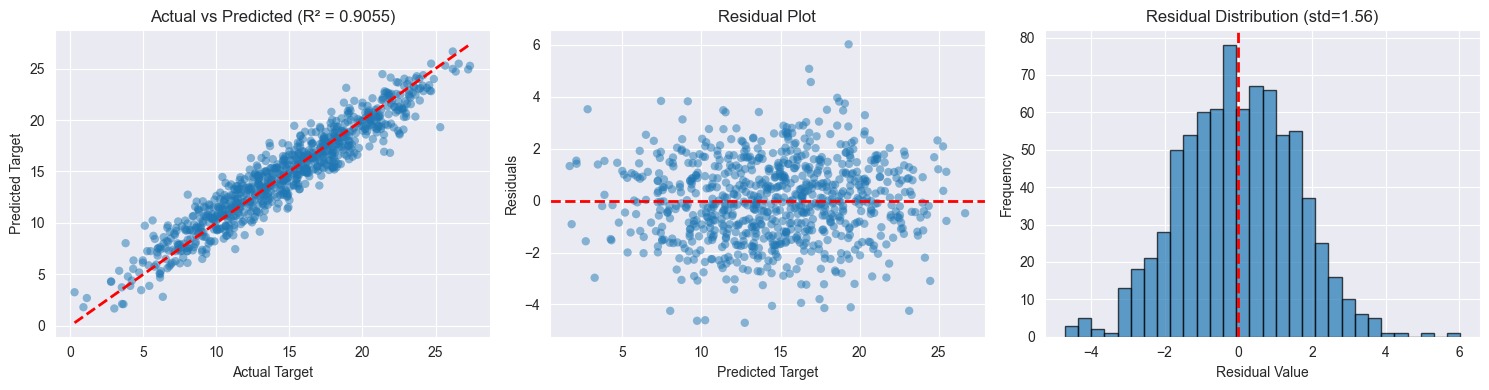

Residuals appear random and normally distributed - good model fit


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y, oof_predictions, alpha=0.5, edgecolors='none')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Target')
axes[0].set_ylabel('Predicted Target')
axes[0].set_title(f'Actual vs Predicted (R² = {oof_r2:.4f})')

residuals = y - oof_predictions
axes[1].scatter(oof_predictions, residuals, alpha=0.5, edgecolors='none')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Target')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title(f'Residual Distribution (std={residuals.std():.2f})')

plt.tight_layout()
plt.show()

print("Residuals appear random and normally distributed - good model fit")

### 6. Generate Predictions for Blind Test Set

In [ ]:
test_predictions = final_pipeline.predict(X_test_selected)

print("BLIND TEST PREDICTIONS")

print(f"\nPrediction Statistics:")
print(f"  Count: {len(test_predictions)}")
print(f"  Mean:  {test_predictions.mean():.4f} (Training: {y.mean():.4f})")
print(f"  Std:   {test_predictions.std():.4f} (Training: {y.std():.4f})")
print(f"  Min:   {test_predictions.min():.4f} (Training: {y.min():.4f})")
print(f"  Max:   {test_predictions.max():.4f} (Training: {y.max():.4f})")

submission_df = pd.DataFrame({'target_pred': test_predictions})
display(submission_df.head(10))

BLIND TEST PREDICTIONS

Prediction Statistics:
  Count: 200
  Mean:  14.3161 (Training: 14.6313)
  Std:   5.0484 (Training: 5.0895)
  Min:   1.8637 (Training: 0.2798)
  Max:   25.7690 (Training: 27.3608)


,target_pred
0,13.404022
1,12.568123
2,16.224686
3,12.445517
4,17.358211
5,12.350188
6,19.353639
7,17.844865
8,12.076006
9,9.279879


In [ ]:
OUTPUT_PATH = "/FileStore/tables/blind_test_predictions.csv"

try:
    submission_spark = spark.createDataFrame(submission_df)
    submission_spark.coalesce(1).write.mode("overwrite").option("header", True).csv(OUTPUT_PATH)
    print(f"Predictions saved to {OUTPUT_PATH}")
except:
    submission_df.to_csv("blind_test_predictions.csv", index=False)
    print("Predictions saved to blind_test_predictions.csv")

Predictions saved to blind_test_predictions.csv


### Complete journey
Key insights per step in parenthesis

Step 1: 
Linear Regression (all features): CV R² 0.70. (Baseline established)

Step 2:
Ridge/Lasso (all features):  CV R² 0.70 (Regularization doesn't help linearly)

Step 3:
Random Forest: CV R² 0.78 (Non-linear relationships exist)

Step 4:
Gradient Boosting: CV R² 0.82 (Better, would probably settle for this in production, but still below target)

Step 5: 
Poly2 on all features + Lasso: CV R² 0.83 (Polynomial helps. Non-linear smooth relationship suspected)

Step 6: 
Feature importance analysis (Only 5 features matter, using trees to find importance of low correlation features)

Step 7:
Poly2 on top 5 + Lasso:  CV R² 0.84 (Cleaner signal, removing the noisy features helped a lot)

Step 8:
Poly3 on top 5 + Lasso: CV R² 0.905!!

Step 9:
Poly4 on top 5 + Lasso: CV R² 0.90 (Diminishing returns, most likely due to feature bloat. Didn't even test for overfitting, no need.)

### Final Model

- Pipeline:   StandardScaler,  PolyFeatures(3), StandardScaler, Lasso(α=0.03)

- Features: feature_2, feature_9, feature_11, feature_13, feature_18

- Performance: CV R² = 0.905 (theoretical max ~0.92)